In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import itertools
import gametheory as gt
import csv

ruta_datos = "/Users/jose/Desktop/GameTheory_project/filtered_gene_bc_matrices/hg19/"

adata = sc.read_10x_mtx(ruta_datos, var_names='gene_symbols')

print(adata)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells'


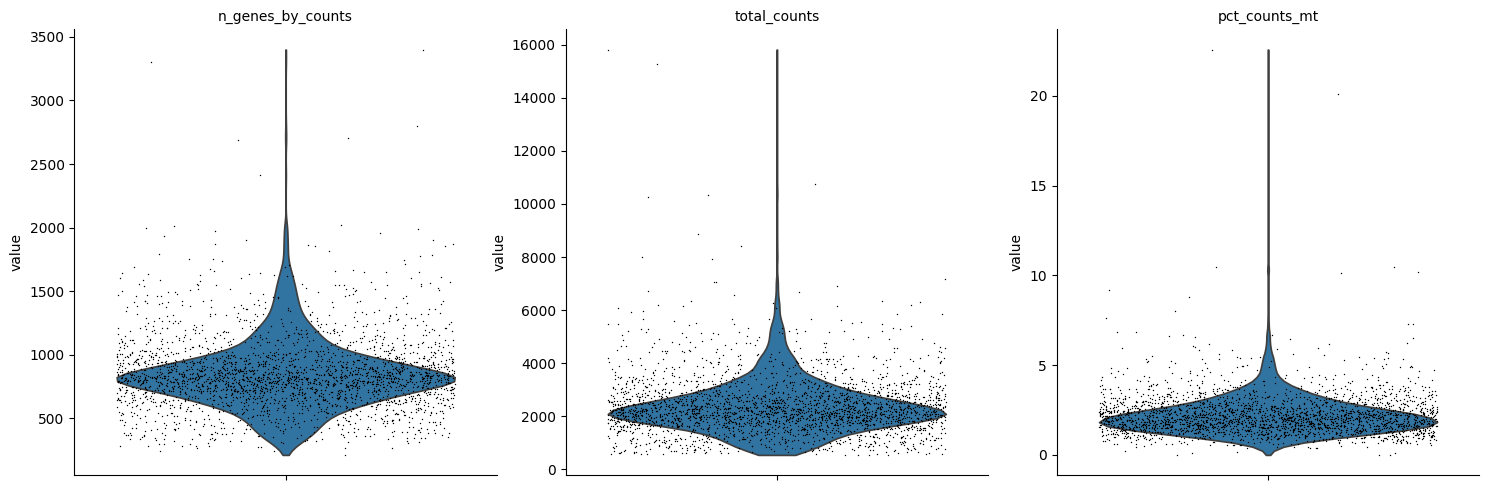

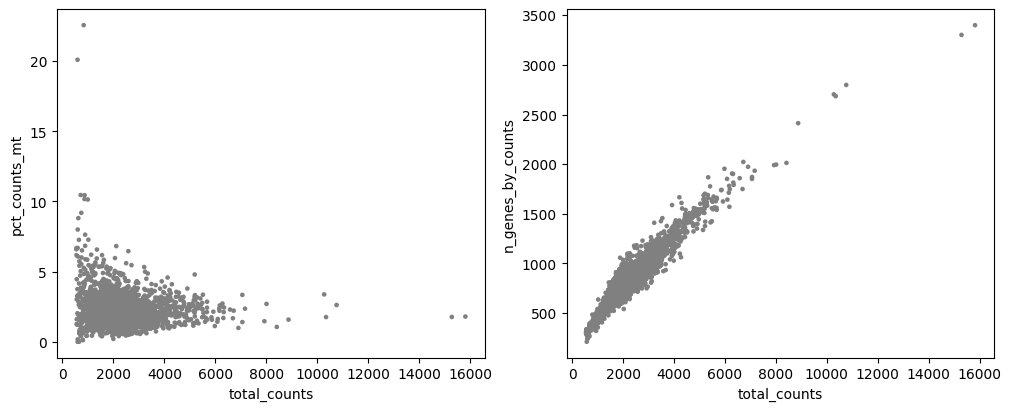

In [2]:
# annotate the group of mitochondrial genes as "mt"
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False, ax=axs[0])
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False, ax=axs[1]);

adata = adata[
    (adata.obs.n_genes_by_counts < 2500)
    & (adata.obs.n_genes_by_counts > 200)
    & (adata.obs.pct_counts_mt < 5),
    :,
].copy()
adata.layers["counts"] = adata.X.copy()

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'counts'


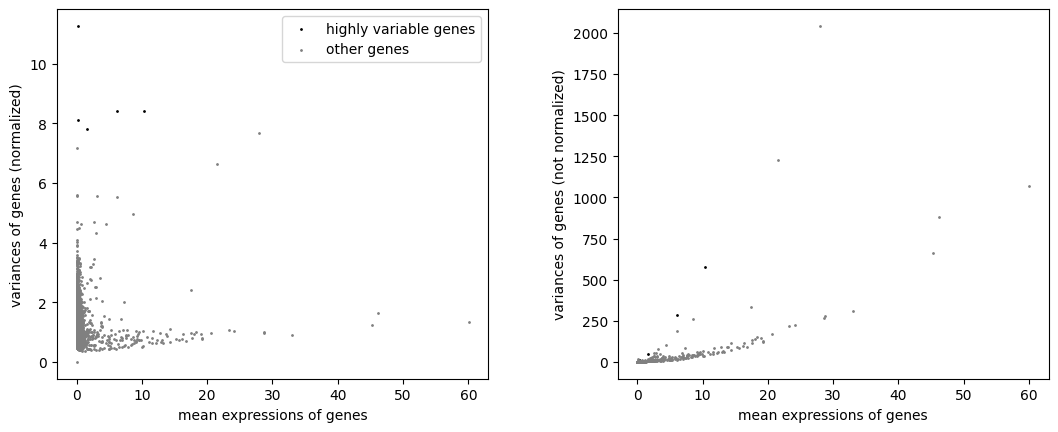

AL627309.1       False
AP006222.2       False
RP11-206L10.2    False
RP11-206L10.9    False
LINC00115        False
                 ...  
AC145212.1       False
AL592183.1       False
AL354822.1       False
PNRC2-1          False
SRSF10-1         False
Name: highly_variable, Length: 13714, dtype: bool
['S100A9', 'GNLY', 'PPBP', 'LYZ', 'IGLL5']


In [3]:
sc.pp.normalize_total(adata, target_sum=1e4)

sc.pp.log1p(adata)

print(adata)

sc.pp.highly_variable_genes(adata,layer="counts",n_top_genes=5,min_mean=0.0125,max_mean=3,min_disp=0.5,flavor="seurat_v3")

sc.pl.highly_variable_genes(adata)

print(adata.var['highly_variable'])

genes_mas_variables = adata.var[adata.var['highly_variable']]

indices_genes_mas_variables = np.where(adata.var['highly_variable'])[0]

#Guardar genes mas variables
genes_mas_variables.to_csv("/Users/jose/Desktop/GameTheory_project/genes_mas_variables.csv")
np.savetxt("/Users/jose/Desktop/GameTheory_project/indices_genes_mas_variables.csv", indices_genes_mas_variables, delimiter=",")

genes_mas_variables_array = np.array(genes_mas_variables)

nombres_genes_mas_variables = adata.var[adata.var['highly_variable']].index.tolist()

print(nombres_genes_mas_variables)

In [4]:
combinaciones_todos_tamanos = []

for r in range(1, len(nombres_genes_mas_variables) + 1):
    combinaciones_todos_tamanos.extend(itertools.combinations(indices_genes_mas_variables, r))

#for combinacion in combinaciones_todos_tamanos:
#   print(combinacion)

#with open("/Users/jose/Desktop/GameTheory_project/combinaciones.csv", "w", newline="") as archivo_csv:
#    escritor = csv.writer(archivo_csv)
#    escritor.writerows(combinaciones_todos_tamanos)

print("Tamaño combinaciones de todos los tamaños:")
print(len(combinaciones_todos_tamanos))

matriz = np.array(adata.layers["counts"].toarray()).T

num_filas, num_columnas = matriz.shape

print(f"Número de filas (genes): {num_filas}")
print(f"Número de columnas (células): {num_columnas}")

ganancias = {}

for combinacion in combinaciones_todos_tamanos:
    
    #print(combinacion)
    ganancias[combinacion] = gt.calcular_CV_grupo_genes(matriz, np.array(combinacion))

print("Ganancias de todas las coaliciones:")

i=0
gan = np.zeros(len(ganancias))

for combinacion, valor in ganancias.items():
    gan[i] = valor
    print(f"Combinación: {combinacion}, Coeficiente de variación: {valor}")
    i += 1
#np.savetxt("/Users/jose/Desktop/GameTheory_project/CoeficienteVariacionCoaliciones.csv", ganancias, delimiter=",",fmt="%.2f")


Tamaño combinaciones de todos los tamaños:
31
Número de filas (genes): 13714
Número de columnas (células): 2638
Ganancias de todas las coaliciones:
Combinación: (np.int64(907),), Coeficiente de variación: 46.23371896711655
Combinación: (np.int64(1803),), Coeficiente de variación: 28.877809616448644
Combinación: (np.int64(3315),), Coeficiente de variación: 39.37632676269901
Combinación: (np.int64(8681),), Coeficiente de variación: 55.25816002652766
Combinación: (np.int64(13274),), Coeficiente de variación: 32.54519301671046
Combinación: (np.int64(907), np.int64(1803)), Coeficiente de variación: 40.480904657530644
Combinación: (np.int64(907), np.int64(3315)), Coeficiente de variación: 45.66641457913232
Combinación: (np.int64(907), np.int64(8681)), Coeficiente de variación: 87.89758969338052
Combinación: (np.int64(907), np.int64(13274)), Coeficiente de variación: 45.15851503163255
Combinación: (np.int64(1803), np.int64(3315)), Coeficiente de variación: 29.877752687544955
Combinación: (np.

In [ ]:
y = gt.shapley_values(indices_genes_mas_variables, {frozenset(k): v for k, v in ganancias.items()})    

print("Valores de Shapley:")

for jugador, valor_shap in y.items(): 
    print(f"Jugador: {jugador}, Valor Shapley: {valor_shap}")

Valores de Shapley:
Jugador: 907, Valor Shapley: 27.729077759954507
Jugador: 1803, Valor Shapley: 0.609161161760658
Jugador: 3315, Valor Shapley: 7.637410571558287
Jugador: 8681, Valor Shapley: 36.63589954619325
Jugador: 13274, Valor Shapley: 5.6035798248202315
